<a href="https://colab.research.google.com/github/rafelsalgueiro/GallegoSalgueiroVera/blob/main/estudio_binomial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudio completo del problema de k-armed bandit con brazos Binomiales

*Description:* Este notebook realiza un estudio exhaustivo del problema de k-armed bandit utilizando brazos con distribución Binomial. Se comparan los siguientes algoritmos:

- *Epsilon-Greedy* (con distintos valores de ε)
- *UCB1* (con distintos valores de c)
- *Softmax* (con distintas temperaturas τ)

Se analizan métricas de regret acumulado y porcentaje de selección óptima, y se incluye un experimento final de comparación directa entre los tres algoritmos.

 #### El Problema Multi-Armed Bandit
El problema consiste en un agente que debe elegir repetidamente entre k opciones (brazos). Cada opción proporciona una recompensa extraída de una distribución de probabilidad desconocida para esa opción. El objetivo es maximizar la recompensa total (o minimizar el regret acumulado) a lo largo de un horizonte temporal $T$.

En este caso, usamos brazos Binomiales, donde la recompensa representa el número de éxitos obtenidos tras realizar $n$ ensayos independientes, cada uno con una probabilidad de éxito $p$. El valor esperado de un brazo es el producto del número de ensayos por su probabilidad, es decir, $n \times p$.

```
Authors: Gallego, Salgueiro y Vera.
Date: 2026/02/16
```

## 1. Preparación del entorno
A continuación están todos los requisitos Python para este estudio, importándose las librerías necesarias.

In [22]:
import numpy as np
 
from src.agents import *
from src.arms import BinomialArm, Bandit
from src.plotting import plot_optimal_selections, plot_regret, plot_average_rewards

# Parámetros del experimento
seed = 42
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

## 2. Definición del bucle experimental
La función `run_experiment` ejecuta cada algoritmo sobre el mismo conjunto de brazos Binomiales durante `n_steps` pasos, repitiendo el proceso `n_runs` veces para obtener resultados promediados.

Se calculan dos métricas:

- **Regret acumulado:** diferencia acumulada entre la recompensa esperada del brazo óptimo y la del brazo seleccionado.
- **Selección óptima:** proporción de veces que se selecciona el brazo con mayor valor esperado.

In [23]:
def run_experiment(bandit: Bandit, agents: list[Agent], steps: int, runs: int):
    optimal_arm = bandit.get_optimal_arm()
    rewards = np.zeros((len(agents), steps))
    optimal_selections = np.zeros((len(agents), steps))

    for run in range(runs):
        current_bandit = Bandit(bandit.arms)
        for agent in agents:
            agent.reset()

        total_rewards_per_agent = np.zeros(len(agents))

        for step in range(steps):
            for idx, agent in enumerate(agents):
                action = agent.get_action()
                reward = current_bandit.pull_arm(action)
                agent.update(action, reward)

                rewards[idx, step] += reward
                total_rewards_per_agent[idx] += reward

                if action == optimal_arm:
                    optimal_selections[idx, step] += 1
            
    rewards /= runs
    optimal_selections /= runs
    return rewards, optimal_selections

## 3. Configuración de los brazos Binomiales

Definimos un bandido de 5 brazos con distintas probabilidades de éxito. El brazo con p = 0.9 es el óptimo.

In [24]:
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones
k = 10 # Número de brazos
# Creación del bandit
bandit = Bandit(arms=BinomialArm.generate_arms(k))

def show_bandit_info(bandit: Bandit, title: str):
    print(f"--- {title} ---")
    print(bandit)
    # Obtenemos el índice del brazo óptimo desde el objeto bandit
    optimal_arm_idx = bandit.optimal_arm
    
    # Obtenemos el valor esperado (media) accediendo a ese brazo específico
    optimal_value = bandit.arms[optimal_arm_idx].get_expected_value()
    print(f"Brazo óptimo: {optimal_arm_idx} con media {optimal_value}")

show_bandit_info(bandit, "Bandit Binomial")

--- Bandit Binomial ---
Bandit with 10 arms: ArmBinomial(n=10, p=0.0), ArmBinomial(n=10, p=0.1111111111111111), ArmBinomial(n=10, p=0.2222222222222222), ArmBinomial(n=10, p=0.3333333333333333), ArmBinomial(n=10, p=0.4444444444444444), ArmBinomial(n=10, p=0.5555555555555556), ArmBinomial(n=10, p=0.6666666666666666), ArmBinomial(n=10, p=0.7777777777777777), ArmBinomial(n=10, p=0.8888888888888888), ArmBinomial(n=10, p=1.0)
Brazo óptimo: 9 con media 10.0


### 4. Epsilon-Greedy con distintos valores de ε
#### Teoría: Epsilon-Greedy
El algoritmo Epsilon-Greedy es una de las estrategias más simples para equilibrar exploración y explotación:

- Con probabilidad $1- ε$, explotamos: elegimos el brazo con mayor valor estimado promedio hasta el momento.
- Con probabilidad $ε$, exploramos: elegimos un brazo aleatorio uniformemente.
El parámetro 
 controla este balance. Un 
 alto favorece el descubrimiento rápido pero impide converger completamente al óptimo. Un 
 bajo es más eficiente a largo plazo pero lento al inicio.

Comparamos tres configuraciones del algoritmo Epsilon-Greedy:

- `ε = 0.0` (puramente voraz, sin exploración)
- `ε = 0.01` (exploración mínima)
- `ε = 0.1` (exploración moderada)
- `ε = 0.3` (exploración alta)

In [25]:
# Definir los algoritmos a comparar. En este caso son 4 algoritmos epsilon-greedy con diferentes valores de epsilon.
agents = [
    EpsilonGreedyAgent(k, epsilon=0.0),
    EpsilonGreedyAgent(k, epsilon=0.01),
    EpsilonGreedyAgent(k, epsilon=0.1),
    EpsilonGreedyAgent(k, epsilon=0.3),
    EpsilonDecayAgent(k_arms=k, e_start=1.0, e_end=0.01, lda=0.01),
    EpsilonDecayAgent(k_arms=k, e_start=1.0, e_end=0.01, lda=0.05),
    EpsilonDecayAgent(k_arms=k, e_start=1.0, e_end=0.01, lda=0.1)
]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections = run_experiment(bandit, agents, steps, runs)
optimal_value = bandit.arms[bandit.optimal_arm].get_expected_value()

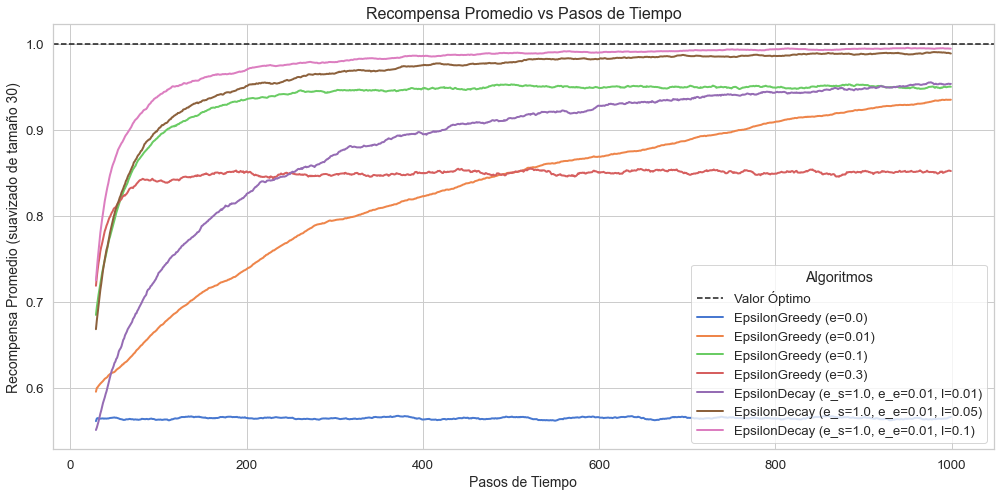

In [26]:
plot_average_rewards(steps, rewards, agents, optimal_value=1,  window_size=30) # Optimal value es 1 porque esta normalizado a [0, 1]

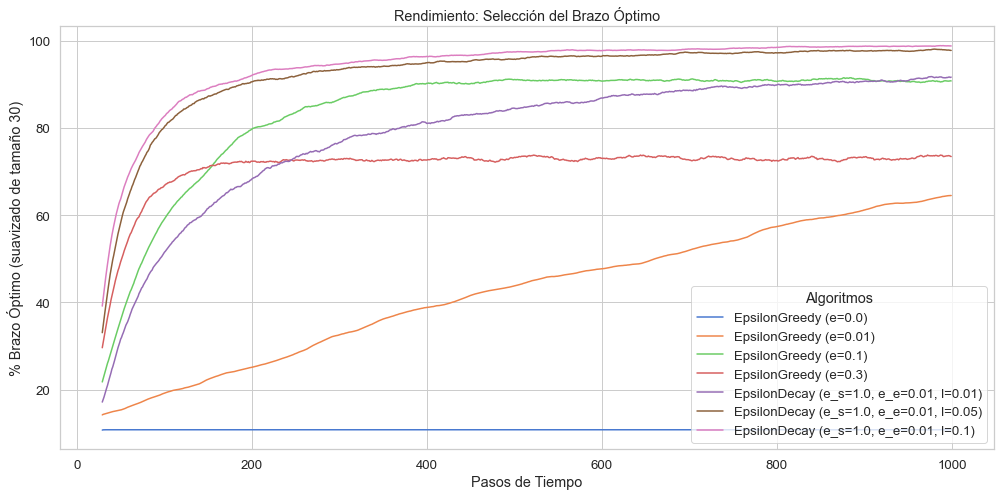

In [27]:
# Gráfica de selección óptima para Epsilon-Greedy
plot_optimal_selections(steps, optimal_selections, agents, window_size=30)

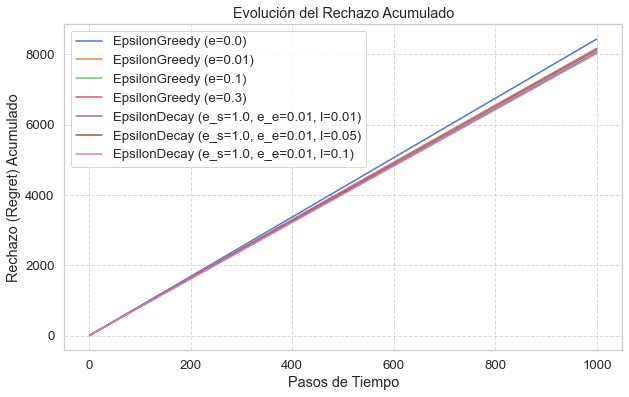

In [28]:
optimal_value = bandit.optimal_arm
regret_per_step = optimal_value - rewards
cumulative_regret = np.cumsum(regret_per_step, axis=1)

plot_regret(steps, cumulative_regret, agents)

### Análisis de Resultados (Epsilon-Greedy con y sin Decay)

## 5. UCB1 con distintos valores de c

### Teoría: UCB1 (Upper Confidence Bound)

UCB1 sigue el principio de \"optimismo ante la incertidumbre\". En lugar de usar una aleatoriedad fija como Epsilon-Greedy, UCB1 calcula un índice de confianza para cada brazo y elige el que tiene el límite superior más alto:

$$ A_t = \\arg\\max_a \\left[ Q_t(a) + c \\sqrt{\\frac{\\ln t}{N_t(a)}} \\right] $$

- El primer término $Q_t(a)$ fomenta la explotación (brazos con buen promedio).
- El segundo término fomenta la exploración de brazos poco visitados (donde $N_t(a)$ es pequeño).
- A medida que el tiempo $t$ avanza, el término de exploración decrece, permitiendo que el algoritmo converja naturalmente al brazo óptimo sin necesidad de reducir un parámetro manualmente.

El parámetro `c` controla el grado de exploración en la fórmula UCB1:

$$Q(a) + c \\cdot \\sqrt{\\frac{\\ln(t)}{N(a)}}$$

Comparamos:
- `c = 0.5` (exploración conservadora)
- `c = 1.0` (exploración moderada)
- `c = 2.0` (exploración estándar)
- `c = 4.0` (exploración agresiva)

In [29]:
# Definir agentes UCB1 con distintos parámetros c
agents = [
    UCBAgent(k_arms=k, c=0.5), 
    UCBAgent(k_arms=k, c=1.0), 
    UCBAgent(k_arms=k, c=2.0), 
    UCBAgent(k_arms=k, c=4.0)
]

rewards, optimal_selections = run_experiment(bandit, agents, steps, runs)
optimal_value = bandit.arms[bandit.optimal_arm].get_expected_value()

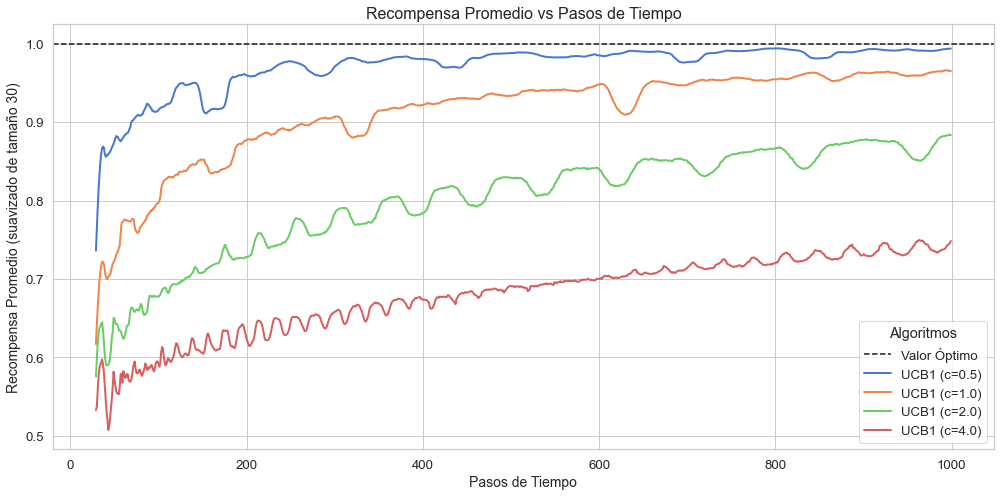

In [30]:
plot_average_rewards(steps, rewards, agents, optimal_value=1, window_size=30)

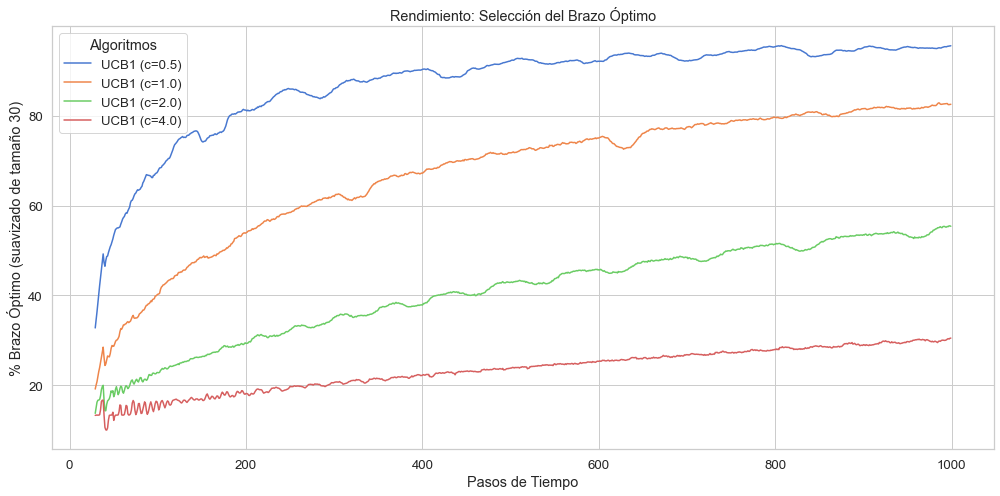

In [31]:
plot_optimal_selections(steps, optimal_selections, agents, window_size=30)

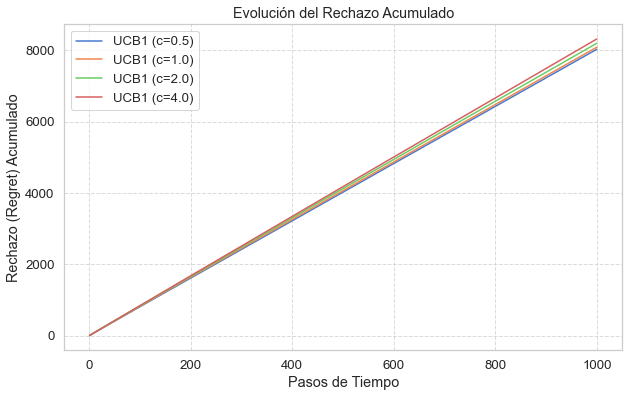

In [32]:
optimal_value = bandit.optimal_arm
regret_per_step = optimal_value - rewards
cumulative_regret = np.cumsum(regret_per_step, axis=1)

plot_regret(steps, cumulative_regret, agents)

### Análisis de Resultados (UCB1)

1. **Estabilidad:** En contraste con Epsilon-Greedy, UCB1 demuestra ser un algoritmo mucho más sólido y consistente. Su principal ventaja es que funciona adecuadamente de forma natural, sin exigir una calibración de parámetros tan minuciosa.
2. **Convergencia:** El modelo consigue localizar la mejor acción y, lo que es fundamental, disminuye progresivamente su necesidad de explorar. Este comportamiento queda reflejado en su curva de regret, la cual presenta un crecimiento logarítmico (más atenuado) en lugar de un aumento lineal constante.
3. **Impacto de $c$:** Configurar el parámetro c con cifras elevadas (como 4.0) induce un exceso de exploración en los primeros pasos, asimilándose a una selección puramente al azar. Por el contrario, utilizar valores reducidos acelera la convergencia, aunque conlleva el peligro de descartar prematuramente la mejor opción si se obtienen bajas recompensas al principio.

## 6. Softmax con distintas temperaturas $τ$
### Teoría: Softmax (Boltzmann Exploration)
El algoritmo **Softmax** elige brazos probabilísticamente, donde la probabilidad de elegir un brazo es proporcional a su valor estimado. Se usa la distribución de Boltzmann:
$$ P(a) = \\frac{e^{Q_t(a)/\\tau}}{\\sum_{b=1}^k e^{Q_t(b)/\\tau}} $$

- Si $\\tau \\to \\infty$, las probabilidades tienden a ser uniformes (exploración pura).
- Si $\\tau \\to 0$, la probabilidad se concentra en el brazo con mayor valor (explotación pura / Greedy).

La ventaja sobre Epsilon-Greedy es que cuando explora, prefiere brazos \"prometedores\" (segundos mejores) sobre los claramente malos, en lugar de elegir cualquiera al azar.
"El parámetro $\\tau$ (temperatura) controla la distribución de probabilidad de selección:
- $\\tau$ bajo: El agente es más decisivo (concentra la probabilidad en el brazo con mayor Q estimado).
- $\\tau$ alto: Las probabilidades se igualan, generando exploración uniforme.

Comparamos:
- `τ = 0.01` (casi determinista)
- `τ = 0.1` (selectivo)
- `τ = 0.5` (moderado)
- `τ = 1.0` (más uniforme)

In [33]:
# Definir los algoritmos a comparar. En este caso son 4 algoritmos softmax con diferentes valores de temperatura.
agents = [SoftmaxAgent(k_arms=k, temperature=0.01), 
          SoftmaxAgent(k_arms=k, temperature=0.1), 
          SoftmaxAgent(k_arms=k, temperature=0.5), 
          SoftmaxAgent(k_arms=k, temperature=1.0)
]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections = run_experiment(bandit, agents, steps, runs)
optimal_value = bandit.arms[bandit.optimal_arm].get_expected_value()

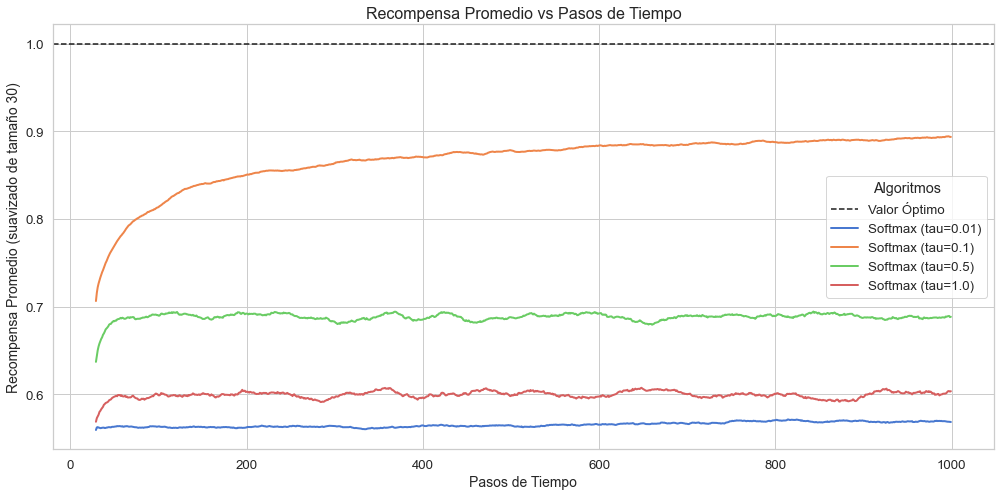

In [34]:
plot_average_rewards(steps, rewards, agents, optimal_value=1, window_size=30)

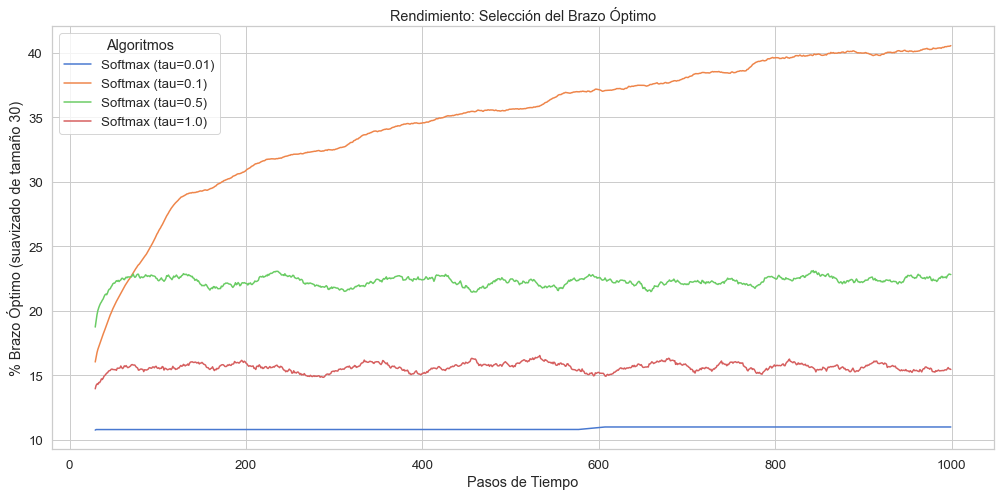

In [35]:
plot_optimal_selections(steps, optimal_selections, agents, window_size=30)

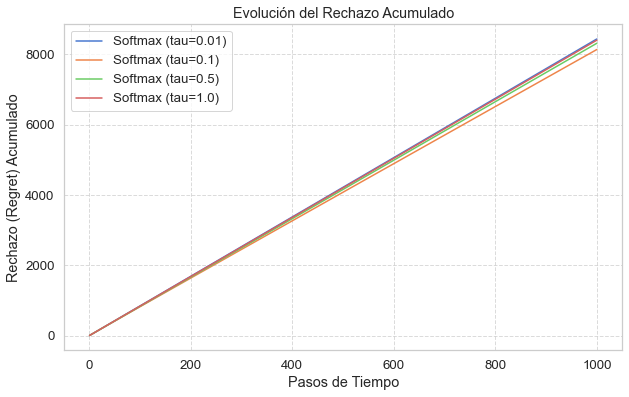

In [42]:
optimal_value = bandit.optimal_arm
regret_per_step = optimal_value - rewards
cumulative_regret = np.cumsum(regret_per_step, axis=1)

plot_regret(steps, cumulative_regret, agents)

### Análisis de Resultados (Softmax)

1. **Sensibilidad a $\\tau$:** El desempeño de Softmax depende fuertemente de la temperatura elegida. Si este valor no se ajusta adecuadamente, los resultados del modelo pueden empeorar drásticamente.
2. **Comportamiento:** Con $\\tau=0.1$, el algoritmo suele ofrecer excelentes resultados, posicionándose frecuentemente por encima de Epsilon-Greedy. Esto se debe a que aplica una exploración más "astuta", evitando de forma natural las opciones que dan las peores recompensas.
3. **Limitación:** De manera similar a lo que ocurre en Epsilon-Greedy con un $\epsilon$ fijo, un algoritmo Softmax con un $\tau$ inalterable nunca dejará de explorar por completo a largo plazo (salvo que apliquemos un mecanismo de enfriamiento gradual, algo que no estamos contemplando en esta configuración).

## 7. Comparación entre todos los algoritmos
### Comparación Directa

Ahora enfrentamos a los \"campeones\" de cada categoría. Esto nos permite ver qué estrategia domina bajo las mismas condiciones. Esperamos ver que UCB1 ofrezca el mejor equilibrio entre estabilidad y rendimiento a largo plazo.
Seleccionamos la mejor configuración de cada algoritmo y los enfrentamos en el mismo problema:
- **ε-Greedy** con ε = 0.1
- **UCB1** con c = 0.5
- **Softmax** con τ = 0.1

In [37]:
agents_comp = [
    EpsilonGreedyAgent(k, epsilon=0.1),
    UCBAgent(k, c=0.5),
    SoftmaxAgent(k, temperature=0.1),
]

regret_comp, optimal_comp = run_experiment(
    bandit, agents_comp, steps=steps, runs=runs
)

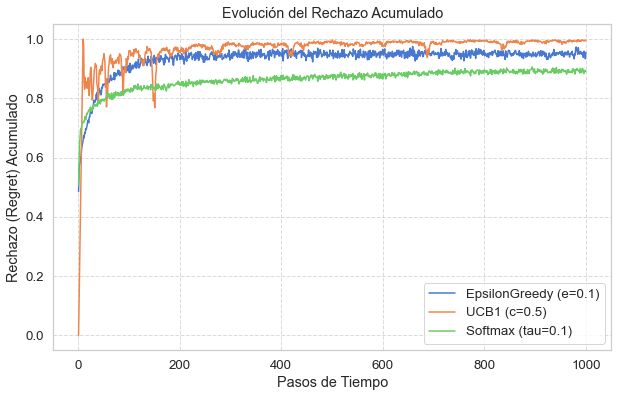

In [38]:
plot_regret(steps, regret_comp, agents_comp)

Observamos que UCB1 es el que tiene un mejor comportamioento respecto a las mejores versiones de los otros métodos.

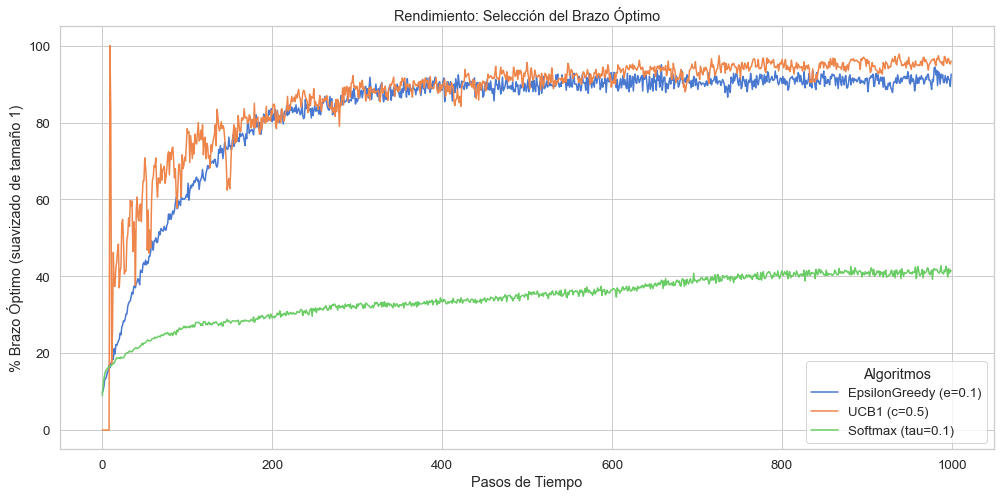

In [39]:
plot_optimal_selections(steps, optimal_comp, agents_comp)

UCB1 es el que mejor converge a una selección optima de forma consistente, softmax es más estable pero acrece de forma más lenta que el epsilon greedy.

#### Análisis Comparativo

La gráfica anterior resume el rendimiento relativo. A continuación, mostramos los valores finales numéricos para una comparación precisa:

In [40]:
print("{:<15} | {:<15} | {:<15}".format("Algoritmo", "Regret Final", "Selección Óptima %"))
print("-"*55)
for i, agent in enumerate(agents_comp):
    print("{:<15} | {:<15.2f} | {:<15.2f}%".format(
        agent.name, 
        regret_comp[i, -1], 
        optimal_comp[i, -1] * 100
    ))

Algoritmo       | Regret Final    | Selección Óptima %
-------------------------------------------------------
EpsilonGreedy (e=0.1) | 0.95            | 92.60          %
UCB1 (c=0.5)    | 1.00            | 96.00          %
Softmax (tau=0.1) | 0.89            | 41.40          %
